# Interface + AF3 Merge (Step-by-Step)
### junjiechen
#### 26.04.20
本笔记本实现：L链长度映射、dSASA_int_per_res计算、与AF3结果合并。

In [1]:
import os
import pandas as pd
from Bio.PDB.PDBParser import PDBParser

In [2]:
sc_path = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/2_combine_af3_train/rosetta_relax/interface/af3_samples-interface-betajan25-nopackinput.sc"
af3_metrics_csv = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/2_combine_af3_train/data/af3_selected_three_points_per_complex.csv"
minimized_dir = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/minimized"
output_csv_path = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/2_combine_af3_train/data/source-nopackinput/af3_rosetta.csv"

In [3]:
pdb_l_len = {}
parser = PDBParser(QUIET=True)

for pdb_file in os.listdir(minimized_dir):
    if not pdb_file.endswith(".pdb"):
        continue

    structure = parser.get_structure(pdb_file[:-4], os.path.join(minimized_dir, pdb_file))
    l_len = None
    for model in structure:
        if "L" in model:
            l_len = len(model["L"])
            break

    if l_len is None:
        continue

    pdb_id = pdb_file[:4].lower()
    pdb_l_len[pdb_id] = l_len

print(f"Loaded L-chain lengths for {len(pdb_l_len)} PDB IDs.")

Loaded L-chain lengths for 170 PDB IDs.


- 如果sc文件是对所有的几何优化后的界面进行打分，需要先按照relax的能量最小结构提取出来后再分析

In [4]:
df_rosetta = pd.read_csv(sc_path, sep=r"\s+", skiprows=1)
print(df_rosetta.shape)
df_rosetta.head(3)


(3210, 50)


,SCORE:,total_score,complex_normalized,dG_cross,dG_cross/dSASAx100,dG_separated,dG_separated/dSASAx100,dSASA_hphobic,dSASA_int,dSASA_polar,...,per_residue_energy_int,pro_close,rama_prepro,ref,sc_value,side1_normalized,side1_score,side2_normalized,side2_score,description
0,SCORE:,-128.852,-1.79,-28.950,-2.947,-17.197,-1.751,588.248,982.227,393.979,...,-2.007,0.591,1.977,-20.166,0.861,-2.461,-29.531,-1.401,-12.613,1a0n_3_seed-43_sample-0_model_0001_0001
1,SCORE:,-87.132,-1.21,-21.418,-2.544,-14.050,-1.669,558.851,841.800,282.949,...,-2.394,0.667,3.080,-25.433,0.872,-2.896,-31.854,-1.605,-11.237,1a0n_1_seed-42_sample-2_model_0003_0001
2,SCORE:,-45.356,-0.63,-20.450,-2.048,-5.133,-0.514,612.959,998.412,385.453,...,-0.501,0.393,20.177,-21.480,0.796,-1.922,-23.066,1.394,12.543,1a0n_10_seed-44_sample-0_model_0002_0001


In [5]:

df_rosetta["description"] = (
    df_rosetta["description"]
    .astype(str)
    .str.split("_")
    .str[:5]
    .str.join("_")
)
df_rosetta["pdb_id"] = df_rosetta["description"].str[:4].str.lower()
df_rosetta["L_chain_length"] = df_rosetta["pdb_id"].map(pdb_l_len)

missing_len_count = df_rosetta["L_chain_length"].isna().sum()
print(f"Rows with missing L-chain length: {missing_len_count}")
df_rosetta[["description", "pdb_id", "L_chain_length"]].head(5)

Rows with missing L-chain length: 0


,description,pdb_id,L_chain_length
0,1a0n_3_seed-43_sample-0_model,1a0n,14
1,1a0n_1_seed-42_sample-2_model,1a0n,14
2,1a0n_10_seed-44_sample-0_model,1a0n,14
3,1a0n_10_seed-43_sample-3_model,1a0n,14
4,1a0n_1_seed-44_sample-4_model,1a0n,14


In [9]:
df_rosetta["dSASA_int_per_res"] = pd.NA
df_rosetta["Hbond_per_res"] = pd.NA
valid_len_mask = df_rosetta["L_chain_length"].notna() & (df_rosetta["L_chain_length"] != 0)
df_rosetta.loc[valid_len_mask, "dSASA_int_per_res"] = (
    df_rosetta.loc[valid_len_mask, "dSASA_int"] / df_rosetta.loc[valid_len_mask, "L_chain_length"]
).round(3)
df_rosetta.loc[valid_len_mask, "Hbond_per_res"] = (
    df_rosetta.loc[valid_len_mask, "hbonds_int"] / df_rosetta.loc[valid_len_mask, "L_chain_length"]
).round(3)
df_rosetta[["description", "dSASA_int", "L_chain_length", "dSASA_int_per_res", "Hbond_per_res", "per_residue_energy_int", "sc_value"]].head(5)

,description,dSASA_int,L_chain_length,dSASA_int_per_res,Hbond_per_res,per_residue_energy_int,sc_value
0,1a0n_3_seed-43_sample-0_model,982.227,14,70.159,0.286,-2.007,0.861
1,1a0n_1_seed-42_sample-2_model,841.800,14,60.129,0.286,-2.394,0.872
2,1a0n_10_seed-44_sample-0_model,998.412,14,71.315,0.286,-0.501,0.796
3,1a0n_10_seed-43_sample-3_model,923.691,14,65.978,0.0,0.663,0.699
4,1a0n_1_seed-44_sample-4_model,863.899,14,61.707,0.286,-2.104,0.793


In [10]:
df_af3 = pd.read_csv(af3_metrics_csv)
print(df_af3.shape)
df_af3.head(3)

(3300, 14)


,source_index,complex,seed,id,pep_plddt,iptm,ranking_score,scRMSD,label,target,d_threshold,selection_role,has_pos,has_neg
0,2,1a0n_1,42,2,82.0692,0.68,0.80,2.1995,0,1a0n,0.321189,best,False,True
1,8,1a0n_1,43,3,82.7624,0.70,0.81,3.7169,0,1a0n,0.669080,worst,False,True
2,14,1a0n_1,44,4,82.9869,0.70,0.81,2.5236,0,1a0n,0.194967,near_threshold,False,True


In [11]:
df_af3["seed"] = pd.to_numeric(df_af3["seed"], errors="coerce").astype("Int64")
df_af3["id"] = pd.to_numeric(df_af3["id"], errors="coerce").astype("Int64")
df_af3["description"] = (
    df_af3["complex"].astype(str)
    + "_seed-" + df_af3["seed"].astype(str)
    + "_sample-" + df_af3["id"].astype(str)
    + "_model"
)

df_af3[["complex", "seed", "id", "description"]].head(5)

,complex,seed,id,description
0,1a0n_1,42,2,1a0n_1_seed-42_sample-2_model
1,1a0n_1,43,3,1a0n_1_seed-43_sample-3_model
2,1a0n_1,44,4,1a0n_1_seed-44_sample-4_model
3,1a0n_10,44,0,1a0n_10_seed-44_sample-0_model
4,1a0n_10,43,3,1a0n_10_seed-43_sample-3_model


In [16]:
rosetta_metrics = df_rosetta[[
    "description",
    "dSASA_int_per_res",
    "dSASA_int",
    "dG_separated/dSASAx100",
    "per_residue_energy_int",
    "sc_value",
    "hbonds_int",
    "Hbond_per_res"
]].rename(columns={"per_residue_energy_int": "energy_per_intres", "hbonds_int":"Hbonds_int"})

rosetta_metrics.head(5)

,description,dSASA_int_per_res,dSASA_int,dG_separated/dSASAx100,energy_per_intres,sc_value,Hbonds_int,Hbond_per_res
0,1a0n_3_seed-43_sample-0_model,70.159,982.227,-1.751,-2.007,0.861,4.0,0.286
1,1a0n_1_seed-42_sample-2_model,60.129,841.800,-1.669,-2.394,0.872,4.0,0.286
2,1a0n_10_seed-44_sample-0_model,71.315,998.412,-0.514,-0.501,0.796,4.0,0.286
3,1a0n_10_seed-43_sample-3_model,65.978,923.691,0.610,0.663,0.699,0.0,0.0
4,1a0n_1_seed-44_sample-4_model,61.707,863.899,-2.521,-2.104,0.793,4.0,0.286


In [ ]:
# 

In [17]:
merged_df = df_af3.merge(rosetta_metrics, on="description", how="inner")

ordered_cols = [
    col for col in df_af3.columns if col != "description"
] + [
    col for col in rosetta_metrics.columns if col != "description"
] + [
    "description"
]

merged_df = merged_df[ordered_cols]

print(merged_df.shape)
merged_df.head(5)

(3210, 22)


,source_index,complex,seed,id,pep_plddt,iptm,ranking_score,scRMSD,label,target,...,has_pos,has_neg,dSASA_int_per_res,dSASA_int,dG_separated/dSASAx100,energy_per_intres,sc_value,Hbonds_int,Hbond_per_res,description
0,2,1a0n_1,42,2,82.0692,0.68,0.80,2.1995,0,1a0n,...,False,True,60.129,841.800,-1.669,-2.394,0.872,4.0,0.286,1a0n_1_seed-42_sample-2_model
1,8,1a0n_1,43,3,82.7624,0.70,0.81,3.7169,0,1a0n,...,False,True,60.555,847.771,-1.749,-1.520,0.861,3.0,0.214,1a0n_1_seed-43_sample-3_model
2,14,1a0n_1,44,4,82.9869,0.70,0.81,2.5236,0,1a0n,...,False,True,61.707,863.899,-2.521,-2.104,0.793,4.0,0.286,1a0n_1_seed-44_sample-4_model
3,25,1a0n_10,44,0,80.2376,0.67,0.78,2.7527,0,1a0n,...,False,True,71.315,998.412,-0.514,-0.501,0.796,4.0,0.286,1a0n_10_seed-44_sample-0_model
4,23,1a0n_10,43,3,77.9586,0.61,0.73,5.9476,0,1a0n,...,False,True,65.978,923.691,0.610,0.663,0.699,0.0,0.0,1a0n_10_seed-43_sample-3_model


In [18]:
matched_count = merged_df["complex"].notna().sum()
unmatched_count = merged_df["complex"].isna().sum()

print(f"Rosetta rows: {len(rosetta_metrics)}")
print(f"AF3 rows: {len(df_af3)}")
print(f"Matched rows: {matched_count}")
print(f"Unmatched rows: {unmatched_count}")

merged_df.loc[merged_df["complex"].isna(), ["description"]].head(10)

Rosetta rows: 3210
AF3 rows: 3300
Matched rows: 3210
Unmatched rows: 0


,description


In [19]:
merged_df.to_csv(output_csv_path, index=False)
print(f"Exported merged CSV: {output_csv_path}")

Exported merged CSV: /home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/2_combine_af3_train/data/source-nopackinput/af3_rosetta.csv


# 计算GLM结果

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

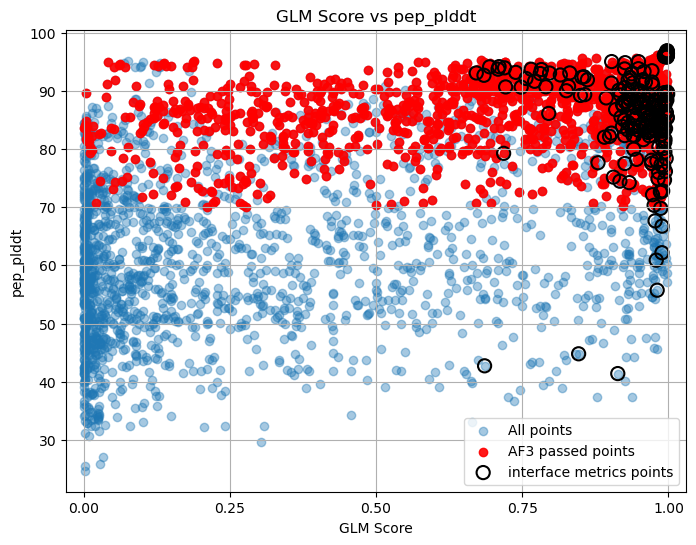

In [22]:
df = pd.read_csv('/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/2_combine_af3_train/data/final_data/af3_rosetta_merged.csv')
df['GLM'] = 1 / (1 + np.exp( - (0.044575 * df['dSASA_int_per_res'] + (-2.118124) * df['dG_separated/dSASAx100'] + (-0.228708) * df['energy_per_intres'] - 9.879178)))
# df['logit'] = -7.642893 + (-1.883335) * df['dG_separated/dSASAx100'] + (-0.259190) * df['energy_per_intres'] + (0.027662) * df['dSASA_int_per_res']
# df['GLM'] = 1 / (1 + np.exp(-df['logit']))

# df.to_csv('/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/validation/af3_design/2_interface/af3_interface_merged_with_GLM.csv', index=False)

df_filtered = df[(df['scRMSD'] < 2.5) & (df['pep_plddt'] >= 70) & (df['iptm'] >= 0.7)]

plt.figure(figsize=(8, 6))

# 全部点
plt.scatter(df['GLM'], df['pep_plddt'], alpha=0.4, label='All points')

# 将筛选后的点标红
plt.scatter(df_filtered['GLM'], df_filtered['pep_plddt'], color='red', alpha=0.9, label='AF3 passed points')


# 设定阈值（按需修改）
dsasa_thr = 104.3
dg_thr = -2.439
energy_thr = -2.471
dsasa_int_thr = 994.1

# dG_separated/dSASAx100≤-2.439，energy_per_intres≤-2.471，dSASA_int≥994.1， dSASA_int_per_res≥104.3

threshold_mask = (
    (df["dSASA_int_per_res"] >= dsasa_thr) &
    (df["dSASA_int"] >= dsasa_int_thr) &
    (df["dG_separated/dSASAx100"] <= dg_thr) &
    (df["energy_per_intres"] <= energy_thr)
)
df_threshold = df.loc[threshold_mask]

# 用黑色边框额外标出满足阈值的点
plt.scatter(
    df_threshold["GLM"],
    df_threshold["pep_plddt"],
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    s=90,
    label="interface metrics points"
)
x_margin = 0.03
plt.xlim(-x_margin, 1 + x_margin)
plt.xticks(np.arange(0, 1.01, 0.25))

plt.xlabel('GLM Score')
plt.ylabel('pep_plddt')
plt.title('GLM Score vs pep_plddt')
plt.grid(True)
plt.legend()
plt.show()



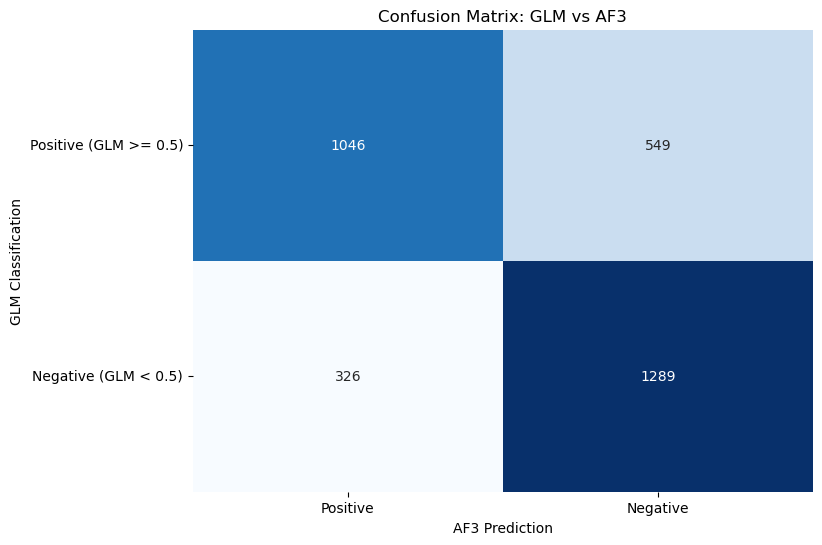

In [24]:
# 纵坐标为AlphaFold3预测的真值结果（label=1），横坐标为GLM预测结果（大于0.5为正类预测）。绘制热图显示GLM预测结果与AlphaFold3预测的真值结果之间的关系。
import seaborn as sns

df_plot = df.assign(GLM_pred=(df["GLM"] >= 0.5).astype(int))

cm = pd.crosstab(df_plot["GLM_pred"], df_plot["label"]).reindex(
    index=[1, 0],   # 纵坐标：上真下假（GLM）
    columns=[1, 0], # 横坐标：左真右假（AF3）
    fill_value=0
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.xlabel("AF3 Prediction")
plt.ylabel("GLM Classification")
plt.title("Confusion Matrix: GLM vs AF3")
plt.xticks([0.5, 1.5], ["Positive", "Negative"])
plt.yticks([0.5, 1.5], ["Positive (GLM >= 0.5)", "Negative (GLM < 0.5)"], rotation=0)
plt.show()



In [25]:
# 输出TPR、FPR、Precision、Recall、F1-score等指标
from sklearn.metrics import confusion_matrix, classification_report
y_true = df_plot["label"]
y_pred = df_plot["GLM_pred"]
print(classification_report(y_true, y_pred, target_names=["AF3 Negative", "AF3 Positive"]))

              precision    recall  f1-score   support

AF3 Negative       0.80      0.70      0.75      1838
AF3 Positive       0.66      0.76      0.71      1372

    accuracy                           0.73      3210
   macro avg       0.73      0.73      0.73      3210
weighted avg       0.74      0.73      0.73      3210



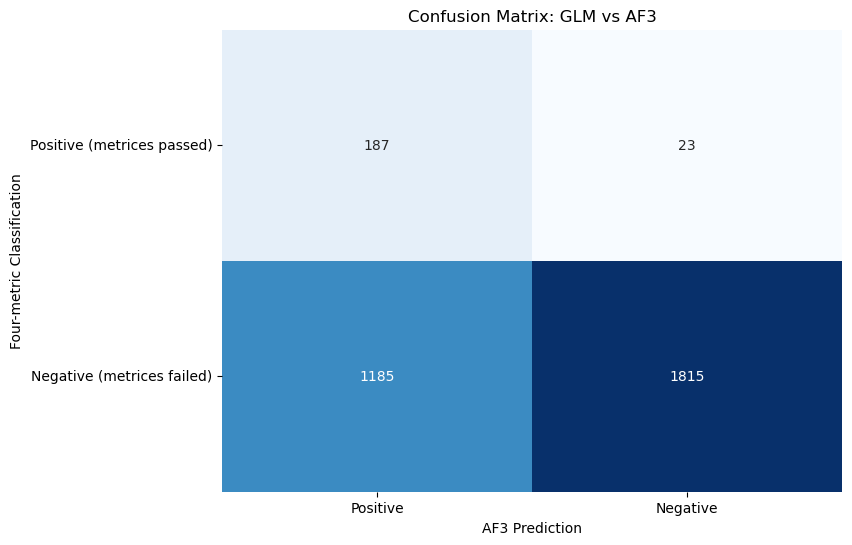

In [16]:
# 使用 threshold_mask 的筛选结果作为“预测类别”，与 AF3 的 label 做混淆矩阵
# 为兼容下方现有代码，沿用列名 GLM_pred：1=通过阈值筛选，0=未通过
import seaborn as sns
df_plot = df.assign(
    GLM_pred=threshold_mask.reindex(df.index, fill_value=False).astype(int)
)

cm = pd.crosstab(df_plot["GLM_pred"], df_plot["label"]).reindex(
    index=[1, 0],   # 纵坐标：上真下假（GLM）
    columns=[1, 0], # 横坐标：左真右假（AF3）
    fill_value=0
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.xlabel("AF3 Prediction")
plt.ylabel("Four-metric Classification")
plt.title("Confusion Matrix: GLM vs AF3")
plt.xticks([0.5, 1.5], ["Positive", "Negative"])
plt.yticks([0.5, 1.5], ["Positive (metrices passed)", "Negative (metrices failed)"], rotation=0)
plt.show()

